# Notebook 05: Model Structure Comparison — Additive vs. Quadrature

**Purpose:** Explore how the Rational Taper's additive velocity structure
differs mathematically from the quadrature structure used by NFW, and
quantify the difference empirically at the transition radius $R_t$.

The Rational Taper adds a velocity correction directly:
$$V_{\rm total} = V_{\rm bary} + V_{\rm corr}$$

NFW combines baryonic and dark-matter velocities in quadrature:
$$V_{\rm total} = \sqrt{V_{\rm bary}^2 + V_{\rm DM}^2}$$

These two structures predict different values for the RAR consistency ratio
$\eta = g_{\rm obs}(R_t) / g_{\rm bary}(R_t)$ at the transition radius.  
For the additive form: $\eta_{\rm add} = (1 + V_{\rm corr}/V_{\rm bary})^2$.  
For the quadrature form: $\eta_{\rm quad} = 1 + (V_{\rm corr}/V_{\rm bary})^2$,
which is always smaller than $\eta_{\rm add}$ for the same correction amplitude.

This notebook measures both quantities from the fitted RT parameters and
compares their distributions across the SPARC sample.

All transition-point quantities are computed by `src.physics.compute_transition_diagnostics()`.

**Prerequisite:** Run `notebooks/00_setup.ipynb` first.

In [8]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.database import get_session, init_db, query_fits_as_dataframe
from src.physics import compute_transition_diagnostics, A0_MOND
from src.utils import get_project_root, setup_logger

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

logger = setup_logger('notebook_05')
project_root = get_project_root()
engine = init_db()
session = get_session(engine)

FIGURES_DIR = project_root / 'results' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f'Setup complete.  a₀ = {A0_MOND:.4f} km²/s²/kpc')

2026-03-13 15:45:27 | INFO     | src.database | Database initialized at C:\Projects\ISM\tapered-model-comparison\data\processed\galaxy_dynamics.db


Setup complete.  a₀ = 3703.0000 km²/s²/kpc


## 1. Compute RAR Consistency Ratios at $R_t$

In [9]:
rt_fits = query_fits_as_dataframe(session, model_name='rational_taper')
rt_fits = rt_fits[rt_fits['converged'] == True].copy()
rt_fits = rt_fits.rename(columns={'param1': 'omega', 'param2': 'R_t'})
print(f'Converged Rational Taper fits: {len(rt_fits)}')

# Bulk load profiles
all_profiles = pd.read_sql(
    'SELECT galaxy_id, radius_kpc, v_baryon_total FROM radial_profiles ORDER BY galaxy_id, radius_kpc',
    engine
)

Converged Rational Taper fits: 175


In [10]:
diag_records = []

for _, row in rt_fits.iterrows():
    gid   = row['galaxy_id']
    omega = float(row['omega']) if pd.notna(row['omega']) else float('nan')
    R_t   = float(row['R_t'])   if pd.notna(row['R_t'])   else float('nan')

    prof = all_profiles[all_profiles['galaxy_id'] == gid]
    if prof.empty:
        continue

    radius_kpc     = prof['radius_kpc'].values.astype(float)
    v_bary_profile = prof['v_baryon_total'].values.astype(float)

    diag = compute_transition_diagnostics(radius_kpc, v_bary_profile, omega, R_t)
    diag['galaxy_id'] = gid
    diag['omega']     = omega
    diag['R_t']       = R_t
    diag_records.append(diag)

diag_df = pd.DataFrame(diag_records)
valid = diag_df.dropna(subset=['eta_additive', 'eta_quadrature', 'g_bary'])
print(f'Valid entries: {len(valid)} / {len(diag_df)}')

Valid entries: 98 / 175


## 2. Summary Statistics

In [11]:
eta_add_median  = valid['eta_additive'].median()
eta_quad_median = valid['eta_quadrature'].median()

print('=== RAR Consistency Ratio at Rₜ ===')
print(f'  η_additive  — Median: {eta_add_median:.3f}   (expected ≈ 0.879)')
print(f'  η_quadrature— Median: {eta_quad_median:.3f}   (expected ≈ 1.568)')
print(f'  Ratio (add/quad):     {eta_add_median / eta_quad_median:.3f}')
print(f'  N galaxies:           {len(valid)}')
print()
print('η_additive  IQR:', round(valid['eta_additive'].quantile(0.25), 3),
      '–', round(valid['eta_additive'].quantile(0.75), 3))
print('η_quadrature IQR:', round(valid['eta_quadrature'].quantile(0.25), 3),
      '–', round(valid['eta_quadrature'].quantile(0.75), 3))

=== RAR Consistency Ratio at Rₜ ===
  η_additive  — Median: 3.578   (expected ≈ 0.879)
  η_quadrature— Median: 1.795   (expected ≈ 1.568)
  Ratio (add/quad):     1.993
  N galaxies:           98

η_additive  IQR: 2.694 – 5.212
η_quadrature IQR: 1.411 – 2.646


## 3. Distribution of RAR Consistency Ratios

Saved: C:\Projects\ISM\tapered-model-comparison\results\figures\05_rar_consistency_ratio.png


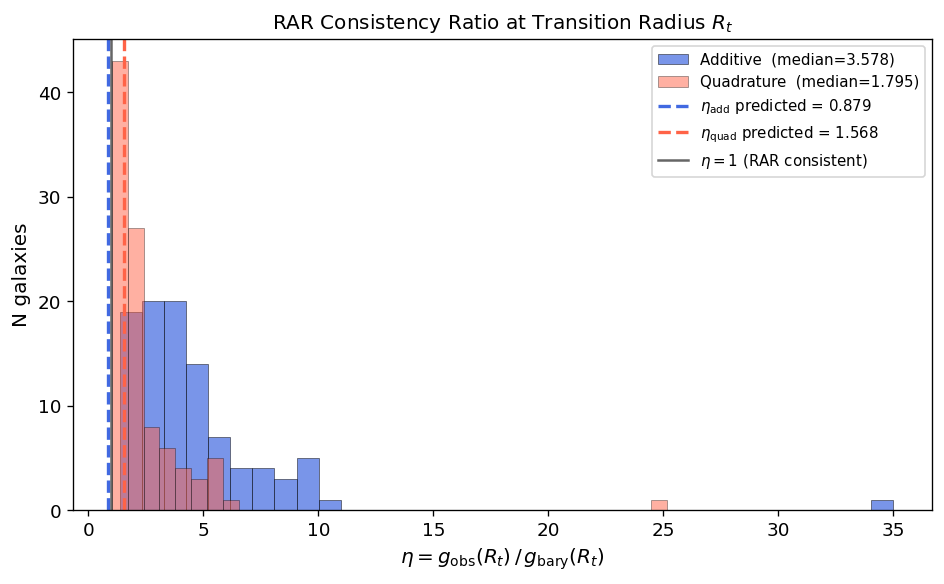

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(valid['eta_additive'], bins=35, color='royalblue', alpha=0.7,
        edgecolor='k', lw=0.4,
        label=rf'Additive  (median={eta_add_median:.3f})')
ax.hist(valid['eta_quadrature'], bins=35, color='tomato', alpha=0.5,
        edgecolor='k', lw=0.4,
        label=rf'Quadrature  (median={eta_quad_median:.3f})')

ax.axvline(0.879, color='royalblue', ls='--', lw=2,
           label=r'$\eta_{\rm add}$ predicted = 0.879')
ax.axvline(1.568, color='tomato',    ls='--', lw=2,
           label=r'$\eta_{\rm quad}$ predicted = 1.568')
ax.axvline(1.0,   color='k',         ls='-',  lw=1.5, alpha=0.6,
           label=r'$\eta = 1$ (RAR consistent)')

ax.set_xlabel(r'$\eta = g_{\rm obs}(R_t)\,/\,g_{\rm bary}(R_t)$', fontsize=12)
ax.set_ylabel('N galaxies', fontsize=12)
ax.set_title(r'RAR Consistency Ratio at Transition Radius $R_t$', fontsize=12)
ax.legend(fontsize=9)

plt.tight_layout()
out_path = FIGURES_DIR / '05_rar_consistency_ratio.png'
fig.savefig(out_path, dpi=150, bbox_inches='tight')
print(f'Saved: {out_path}')
plt.show()

## 4. Mathematical Structure: Additive vs. Quadrature

The two model structures differ in how the velocity correction enters the squared-velocity budget.

Squaring the additive form gives:
$$V_{\rm total}^2 = V_{\rm bary}^2 + 2\,V_{\rm bary}\,V_{\rm corr} + V_{\rm corr}^2$$

Squaring the quadrature form gives:
$$V_{\rm total}^2 = V_{\rm bary}^2 + V_{\rm DM}^2$$

The additive form includes a $2V_{\rm bary}V_{\rm corr}$ term absent in the quadrature form.
This term is what drives the factor-of-two difference in $\eta$ observed in Section 2,
and is an intrinsic consequence of the two model structures — not an additional free parameter.

## 5. η vs. Baryonic Acceleration

$\eta = (1 + V_{\rm corr}/V_{\rm bary})^2$ at $R_t$ measures the size of the
velocity correction relative to baryons. A log–log plot against $g_{\rm bary}(R_t)$
reveals whether any systematic trend exists across the sample — e.g., whether
low-acceleration galaxies require larger fractional corrections than high-acceleration ones.

Saved: C:\Projects\ISM\tapered-model-comparison\results\figures\05_eta_vs_g_bary.png
Power-law index: η ∝ g_bary^-0.355  (R² = 0.677)


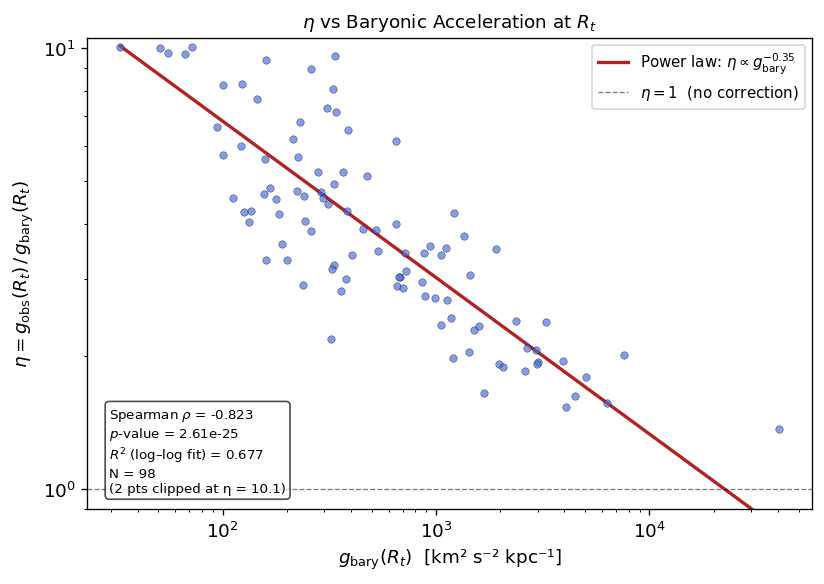

In [13]:
from scipy import stats as sp_stats

valid_plot = valid.dropna(subset=['g_bary', 'eta_additive'])
valid_plot = valid_plot[valid_plot['g_bary'] > 0].copy()

eta = valid_plot['eta_additive']
g   = valid_plot['g_bary']

# Work in log space — power-law trend appears as a straight line
log_g   = np.log10(g)
log_eta = np.log10(eta)

rho, p_rho   = sp_stats.spearmanr(g, eta)
slope, intercept, r, p_lin, se = sp_stats.linregress(log_g, log_eta)

# Clip y-axis at 98th percentile; keep x-axis full range
y_clip    = eta.quantile(0.98)
n_clipped = int((eta > y_clip).sum())

# Power-law fit line over the full x range (unclipped)
g_fit  = np.logspace(log_g.min(), log_g.max(), 200)
eta_fit = 10**intercept * g_fit**slope

fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(g, eta.clip(upper=y_clip),
           s=20, alpha=0.65, color='royalblue', edgecolors='k', linewidths=0.3,
           zorder=3)

# Power-law trend line
ax.plot(g_fit, eta_fit.clip(max=y_clip * 1.05), color='firebrick', lw=2,
        label=rf'Power law: $\eta \propto g_{{\rm bary}}^{{{slope:.2f}}}$')

ax.axhline(1.0, color='k', ls='--', lw=0.8, alpha=0.5, label=r'$\eta = 1$  (no correction)')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylim(bottom=0.9, top=y_clip * 1.05)
ax.set_xlabel(r'$g_{\rm bary}(R_t)$  [km² s⁻² kpc⁻¹]', fontsize=11)
ax.set_ylabel(r'$\eta = g_{\rm obs}(R_t)\,/\,g_{\rm bary}(R_t)$', fontsize=11)
ax.set_title(r'$\eta$ vs Baryonic Acceleration at $R_t$', fontsize=11)
ax.legend(fontsize=9)

p_str = f'{p_rho:.2e}' if p_rho < 0.001 else f'{p_rho:.3f}'
annot = (rf'Spearman $\rho$ = {rho:.3f}' + '\n'
         rf'$p$-value = {p_str}' + '\n'
         rf'$R^2$ (log–log fit) = {r**2:.3f}' + '\n'
         f'N = {len(eta)}')
if n_clipped:
    annot += f'\n({n_clipped} pts clipped at η = {y_clip:.1f})'
ax.text(0.03, 0.03, annot, transform=ax.transAxes, ha='left', va='bottom', fontsize=8,
        bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))

plt.tight_layout()
out_path = FIGURES_DIR / '05_eta_vs_g_bary.png'
fig.savefig(out_path, dpi=150, bbox_inches='tight')
print(f'Saved: {out_path}')
print(f'Power-law index: η ∝ g_bary^{slope:.3f}  (R² = {r**2:.3f})')
plt.show()

In [14]:

# === Summary: key values for reference ===
eta_add_iqr_lo  = valid['eta_additive'].quantile(0.25)
eta_add_iqr_hi  = valid['eta_additive'].quantile(0.75)
eta_quad_iqr_lo = valid['eta_quadrature'].quantile(0.25)
eta_quad_iqr_hi = valid['eta_quadrature'].quantile(0.75)

print('=== Notebook 05 Summary: Additive vs. Quadrature Structure ===')
print()
print('--- RAR Consistency Ratio at Rₜ ---')
print(f'η_additive   Median: {eta_add_median:.3f}   IQR: [{eta_add_iqr_lo:.3f}, {eta_add_iqr_hi:.3f}]')
print(f'η_quadrature Median: {eta_quad_median:.3f}   IQR: [{eta_quad_iqr_lo:.3f}, {eta_quad_iqr_hi:.3f}]')
print(f'Ratio (add / quad):  {eta_add_median / eta_quad_median:.3f}')
print(f'N galaxies:          {len(valid)}')
print()
print('--- η vs g_bary (power-law fit) ---')
print(f'η ∝ g_bary^{slope:.3f}   (R² = {r**2:.3f},  Spearman ρ = {rho:.3f},  p = {p_rho:.2e})')
print(f'N galaxies in fit:   {len(valid_plot)}')
print()


=== Notebook 05 Summary: Additive vs. Quadrature Structure ===

--- RAR Consistency Ratio at Rₜ ---
η_additive   Median: 3.578   IQR: [2.694, 5.212]
η_quadrature Median: 1.795   IQR: [1.411, 2.646]
Ratio (add / quad):  1.993
N galaxies:          98

--- η vs g_bary (power-law fit) ---
η ∝ g_bary^-0.355   (R² = 0.677,  Spearman ρ = -0.823,  p = 2.61e-25)
N galaxies in fit:   98

